# 🤘 Texas Longhorns 2026 — Ticket Price Tracker
Track SeatGeek get-in prices for major Texas football games and visualize how they change over time.

| Game | Date | Location |
|---|---|---|
| vs. Ohio State | Sat Sep 12 | Austin, TX (DKR) |
| vs. Ole Miss | Sat Oct 24 | Austin, TX (DKR) |
| at LSU | Sat Nov 14 | Baton Rouge, LA |
| at Texas A&M | Fri Nov 27 | College Station, TX |

**How to use:**
1. Run **Cell 1** once per session (sets up DB + loads functions)
2. Run **Cell 2** each time you check SeatGeek to log prices
3. Run **Cell 3** anytime to see the trend chart
4. Run **Cell 4** anytime for the full history table


In [1]:
# Now through August: once a week — prices are mostly stable this far out
# September (closer to kickoff): every 2–3 days — prices start moving more
# 1–2 weeks before each game: daily — this is when the biggest swings happen

In [4]:
# CELL 1 — Setup (run once per session)

import subprocess, sqlite3, pandas as pd
from pathlib import Path
from datetime import datetime, date

subprocess.run(["pip", "install", "requests", "matplotlib"], capture_output=True)

DB_PATH = Path("texas_football_prices.db")

GAMES = [
    {
        "id": "g1", "opponent": "Ohio State", "date": "Sep 12",
        "game_date": date(2026, 9, 12),
        "cutoff": datetime(2026, 9, 12, 23, 59),
        "location": "Austin, TX", "home": True,
        "label": "vs. Ohio State  (Sep 12)",
        "color": "#BF5700",  # Burnt orange
    },
    {
        "id": "g2", "opponent": "Ole Miss", "date": "Oct 24",
        "game_date": date(2026, 10, 24),
        "cutoff": datetime(2026, 10, 24, 23, 59),
        "location": "Austin, TX", "home": True,
        "label": "vs. Ole Miss     (Oct 24)",
        "color": "#D4881A",  # Warm amber
    },
    {
        "id": "g3", "opponent": "LSU", "date": "Nov 14",
        "game_date": date(2026, 11, 14),
        "cutoff": datetime(2026, 11, 14, 23, 59),
        "location": "Baton Rouge, LA", "home": False,
        "label": "at LSU           (Nov 14)",
        "color": "#F7C948",  # Gold
    },
    {
        "id": "g4", "opponent": "Texas A&M", "date": "Nov 27",
        "game_date": date(2026, 11, 27),
        "cutoff": datetime(2026, 11, 27, 23, 59),
        "location": "College Station, TX", "home": False,
        "label": "at Texas A&M    (Nov 27)",
        "color": "#E87070",  # Soft red
    },
    {
        "id": "g5", "opponent": "Oklahoma", "date": "Oct 10",
        "game_date": date(2026, 10, 10),
        "cutoff": datetime(2026, 10, 10, 23, 59),
        "location": "Dallas, TX", "home": False,
        "label": "Red River Rivalry (Oct 10)",
        "color": "#8B1A1A",  # Deep crimson
    },
]

# ── Database setup ────────────────────────────────────────────────────────────

conn = sqlite3.connect(DB_PATH)
conn.execute("""
    CREATE TABLE IF NOT EXISTS prices (
        id        INTEGER PRIMARY KEY AUTOINCREMENT,
        game_id   TEXT    NOT NULL,
        price     INTEGER NOT NULL,
        notes     TEXT,
        logged_at TEXT    NOT NULL
    )
""")
conn.commit()
count = conn.execute("SELECT COUNT(*) FROM prices").fetchone()[0]
print(f"Database ready ({count} entries logged)")
conn.close()

# ── Helper functions ──────────────────────────────────────────────────────────

def log_price(game_id, price, notes=""):
    conn = sqlite3.connect(DB_PATH)
    conn.execute(
        "INSERT INTO prices (game_id, price, notes, logged_at) VALUES (?,?,?,?)",
        (game_id, price, notes, datetime.now().isoformat(timespec="seconds"))
    )
    conn.commit()
    conn.close()

def get_all_prices():
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM prices ORDER BY logged_at", conn)
    conn.close()
    if df.empty:
        df["logged_at"] = pd.Series(dtype="datetime64[ns]")
        df["game_label"] = pd.Series(dtype="str")
        return df
    df["logged_at"] = pd.to_datetime(df["logged_at"], format="mixed")
    game_map = {g["id"]: g["label"] for g in GAMES}
    df["game_label"] = df["game_id"].map(game_map)
    return df

def latest_prices():
    df = get_all_prices()
    if df.empty:
        return df
    return df.sort_values("logged_at").groupby("game_id").last().reset_index()

print("Setup complete")


Database ready (16 entries logged)
Setup complete


In [2]:
# CELL 2 — Log prices (run each time you check SeatGeek)

today = date.today()
now = datetime.now()

upcoming = [g for g in GAMES if g["cutoff"] > now]
completed = [g for g in GAMES if g["cutoff"] <= now]

if completed:
    print(f"Skipping {len(completed)} completed game(s): {', '.join(g['date'] for g in completed)}\n")

if not upcoming:
    print("All games have been played. Nothing to log.")
else:
    print("Enter get-in prices from SeatGeek (press Enter to skip):\n")
    latest = latest_prices()
    logged = []

    for game in upcoming:
        row = latest[latest["game_id"] == game["id"]] if not latest.empty else pd.DataFrame()
        prev = int(row.iloc[0]["price"]) if not row.empty else None
        prev_str = f"  (last: ${prev:,})" if prev else ""
        location_str = f"{'Home' if game['home'] else 'Away'} · {game['location']}"

        raw = input(f"  {game['label']}  [{location_str}]{prev_str}: $").strip()
        if not raw:
            continue
        try:
            price = int(raw.replace(",", "").replace("$", ""))
            log_price(game["id"], price)
            if prev:
                diff = price - prev
                arrow = "▲" if diff > 0 else "▼" if diff < 0 else "—"
                print(f"    Saved  {arrow} ${abs(diff):,} from last reading\n")
            else:
                print(f"    Saved\n")
            logged.append(game["label"])
        except ValueError:
            print(f"    Skipped (couldn't parse '{raw}')\n")

    if logged:
        print(f"✅ Logged {len(logged)} price(s). Run Cell 3 to see the updated chart.")
    else:
        print("No prices logged.")


Enter get-in prices from SeatGeek (press Enter to skip):

    Saved  ▲ $30 from last reading

    Saved  — $0 from last reading

    Saved  — $0 from last reading

    Saved  ▼ $17 from last reading

✅ Logged 4 price(s). Run Cell 3 to see the updated chart.


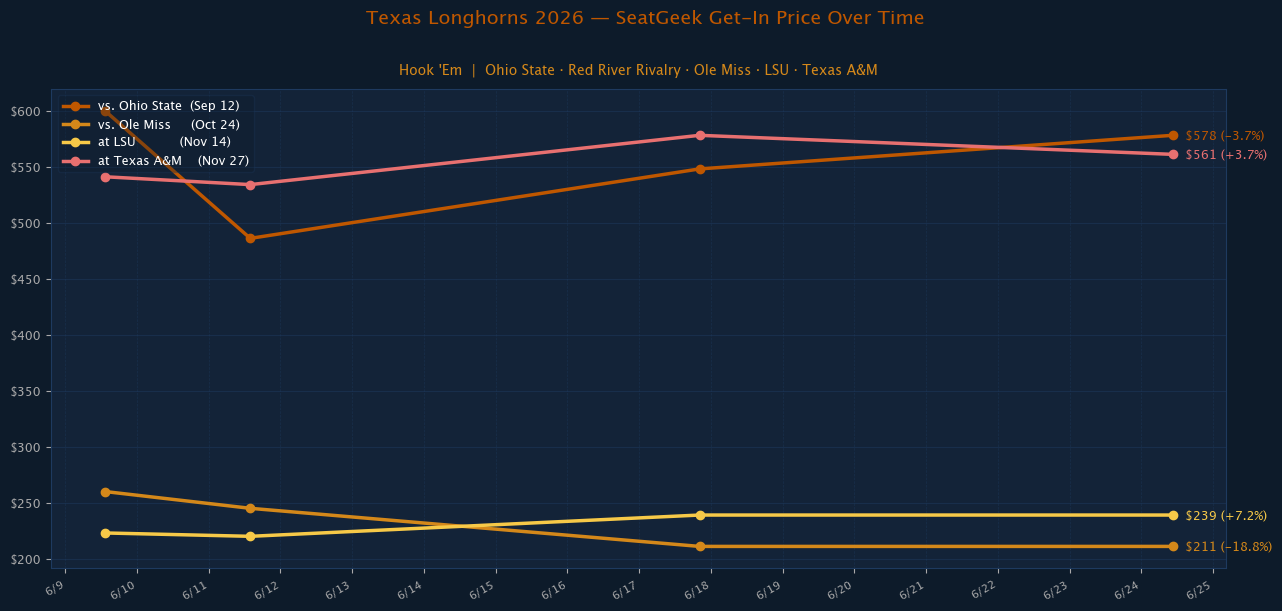

Chart saved as texas_football_chart.png


In [5]:
# CELL 3 — Price trend chart

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = get_all_prices()

NAVY  = "#0D1B2A"
PANEL = "#132338"
GRID  = "#1E3A5F"

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(PANEL)

for spine in ax.spines.values():
    spine.set_edgecolor(GRID)

has_data = False
for game in GAMES:
    gdf = df[df["game_id"] == game["id"]].sort_values("logged_at") if not df.empty else pd.DataFrame()
    if gdf.empty:
        continue
    has_data = True
    ax.plot(
        gdf["logged_at"], gdf["price"],
        marker="o", linewidth=2.5, markersize=6,
        color=game["color"], label=game["label"]
    )
    first_price = int(gdf.iloc[0]["price"])
    last = gdf.iloc[-1]
    last_price = int(last["price"])

    if len(gdf) > 1:
        pct = ((last_price - first_price) / first_price) * 100
        arrow = "+" if pct > 0 else "-"
        pct_str = f"{arrow}{abs(pct):.1f}%"
        label = f"${last_price:,} ({pct_str})"
    else:
        label = f"${last_price:,}"

    ax.annotate(
        label,
        xy=(last["logged_at"], last["price"]),
        xytext=(9, 0), textcoords="offset points",
        fontsize=9, color=game["color"], va="center", fontweight="bold"
    )

if not has_data:
    ax.text(0.5, 0.5, "No prices logged yet.\nRun Cell 2 to add your first entry.",
            ha="center", va="center", transform=ax.transAxes,
            color="#AAAAAA", fontsize=12)
else:
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%-m/%-d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8, color="#AAAAAA")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))
    ax.tick_params(axis="y", labelsize=9, colors="#AAAAAA")
    ax.tick_params(axis="x", colors="#AAAAAA")
    legend = ax.legend(fontsize=9, loc="upper left", framealpha=0.3,
                       facecolor=NAVY, edgecolor=GRID, labelcolor="white")
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--")

fig.suptitle("Texas Longhorns 2026 — SeatGeek Get-In Price Over Time",
             fontsize=14, fontweight="bold", color="#BF5700", y=1.01)
ax.set_title("Hook 'Em  |  Ohio State · Red River Rivalry · Ole Miss · LSU · Texas A&M",
             fontsize=10, color="#D4881A", pad=10)

plt.tight_layout()
plt.savefig("texas_football_chart.png", dpi=150, bbox_inches="tight", facecolor=NAVY)
plt.show()
print("Chart saved as texas_football_chart.png")

In [5]:
# CELL 4 — Full history table

df = get_all_prices()
if df.empty:
    print("No prices logged yet.")
else:
    df_display = df[["game_label", "price", "logged_at", "notes"]].copy()
    df_display.columns = ["Game", "Price", "Logged at", "Notes"]
    df_display["Price"] = df_display["Price"].apply(lambda x: f"${int(x):,}")
    df_display["Logged at"] = df_display["Logged at"].astype(str).str[:16]
    from IPython.display import display
    display(df_display.sort_values("Logged at", ascending=False).reset_index(drop=True))

,Game,Price,Logged at,Notes
0,at LSU (Nov 14),$239,2026-06-17 20:12,
1,at Texas A&M (Nov 27),$578,2026-06-17 20:12,
2,vs. Ohio State (Sep 12),$548,2026-06-17 20:11,
3,vs. Ole Miss (Oct 24),$211,2026-06-17 20:11,
4,vs. Ohio State (Sep 12),$486,2026-06-11 13:54,
5,vs. Ole Miss (Oct 24),$245,2026-06-11 13:54,
6,at LSU (Nov 14),$220,2026-06-11 13:54,
7,at Texas A&M (Nov 27),$534,2026-06-11 13:54,
8,vs. Ole Miss (Oct 24),$260,2026-06-09 13:15,
9,at LSU (Nov 14),$223,2026-06-09 13:15,
